# 02 — Model Architecture
Inspect the VAE architecture, verify forward pass shapes, visualise the
encoder-decoder information flow, and analyse the latent space structure.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from src.models.vae import MorphoSyntaxVAE
from src.utils.cuda_utils import count_parameters, get_device
from src.utils.config_loader import load_config

model_cfg = load_config('model_config', config_dir='../configs')
enc_cfg = model_cfg['encoder']
lat_cfg = model_cfg['latent_space']

# Instantiate a small version for architecture inspection
model = MorphoSyntaxVAE(
    vocab_size=1000,
    embedding_dim=enc_cfg['embedding_dim'],
    hidden_dim=enc_cfg['hidden_dim'],
    z_dim=lat_cfg['z_dim'],
    morpho_dim=lat_cfg['morpho_dim'],
    syntax_dim=lat_cfg['syntax_dim'],
    num_layers=enc_cfg['num_layers'],
    dropout=0.0,
    pad_idx=0,
    encoder_type=enc_cfg['type'],
    prior_type=lat_cfg['prior'],
)

total, trainable = count_parameters(model)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {trainable:,}')
print()
print(model)

Total parameters:     14,945,512
Trainable parameters: 14,945,512

MorphoSyntaxVAE(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(1000, 256, padding_idx=0)
    (lstm): LSTM(256, 512, num_layers=2, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (fc_mu): Linear(in_features=1024, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=1024, out_features=128, bias=True)
  )
  (decoder): LSTMDecoder(
    (embedding): Embedding(1000, 256, padding_idx=0)
    (dropout): Dropout(p=0.0, inplace=False)
    (lstm): LSTM(384, 512, num_layers=2, batch_first=True)
    (output_projection): Linear(in_features=512, out_features=1000, bias=True)
    (z_to_hidden): Linear(in_features=128, out_features=1024, bias=True)
    (z_to_cell): Linear(in_features=128, out_features=1024, bias=True)
  )
  (latent_space): LatentSpace()
  (prior): StandardNormalPrior()
)


In [2]:
# Verify forward pass with dummy data
batch_size = 4
seq_len = 12
token_ids = torch.randint(1, 1000, (batch_size, seq_len))
lengths = torch.tensor([12, 10, 8, 6])

with torch.no_grad():
    output = model(token_ids, lengths)

print('=== Output Shapes ===')
for key, val in output.items():
    print(f'  {key:15s}: {tuple(val.shape)}')

=== Output Shapes ===
  logits         : (4, 11, 1000)
  mu             : (4, 128)
  logvar         : (4, 128)
  z              : (4, 128)
  z_morpho       : (4, 64)
  z_syntax       : (4, 64)


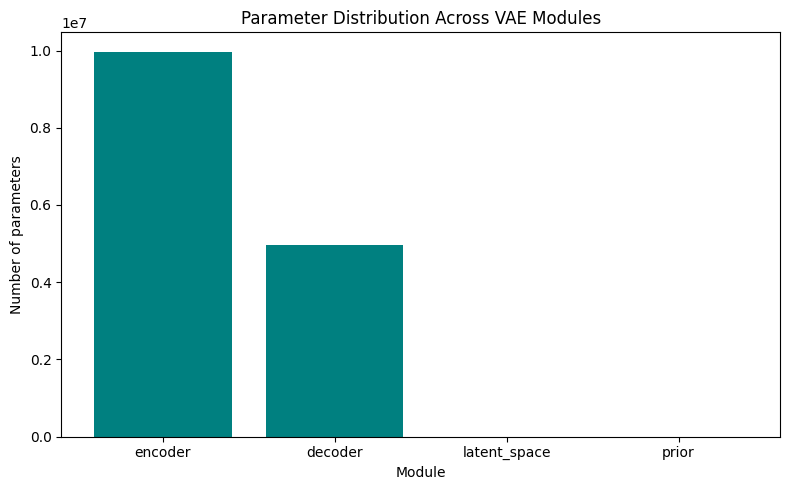

In [3]:
# Visualise parameter distribution across modules
import matplotlib.pyplot as plt

module_params = {}
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    module_params[name] = n_params

plt.figure(figsize=(8, 5))
plt.bar(module_params.keys(), module_params.values(), color='teal')
plt.xlabel('Module')
plt.ylabel('Number of parameters')
plt.title('Parameter Distribution Across VAE Modules')
plt.tight_layout()
plt.savefig('../outputs/figures/parameter_distribution.png', dpi=150)
plt.show()

In [4]:
# Prior sampling and generation test
with torch.no_grad():
    z_prior = model.sample_prior(n_samples=8, device=torch.device('cpu'))
    generated = model.generate(z_prior, bos_idx=2, eos_idx=3, max_len=20)

print(f'Prior samples shape:  {z_prior.shape}')
print(f'Generated sequences:  {generated.shape}')
print(f'Sample generated IDs: {generated[0].tolist()}')

Prior samples shape:  torch.Size([8, 128])
Generated sequences:  torch.Size([8, 20])
Sample generated IDs: [445, 445, 445, 740, 394, 394, 504, 504, 229, 229, 937, 937, 822, 822, 294, 937, 822, 157, 709, 709]


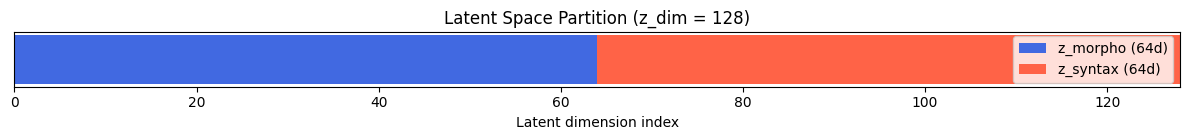

In [5]:
# Latent space split visualisation
import numpy as np
import matplotlib.patches as mpatches

z_dim = lat_cfg['z_dim']
morpho_dim = lat_cfg['morpho_dim']
syntax_dim = lat_cfg['syntax_dim']

fig, ax = plt.subplots(figsize=(12, 1.5))
ax.barh(0, morpho_dim, color='royalblue', label=f'z_morpho ({morpho_dim}d)')
ax.barh(0, syntax_dim, left=morpho_dim, color='tomato', label=f'z_syntax ({syntax_dim}d)')
ax.set_xlim(0, z_dim)
ax.set_yticks([])
ax.set_xlabel('Latent dimension index')
ax.set_title(f'Latent Space Partition (z_dim = {z_dim})')
ax.legend(loc='center right')
plt.tight_layout()
plt.savefig('../outputs/figures/latent_partition.png', dpi=150)
plt.show()